Missing values in remaining columns:
 Day_of_Week                   0
Junction_Control              0
Junction_Detail               0
Accident_Severity             0
Light_Conditions              0
Number_of_Casualties          0
Number_of_Vehicles            0
Road_Surface_Conditions     317
Road_Type                  1534
Speed_limit                   0
Urban_or_Rural_Area           0
Weather_Conditions         6057
Vehicle_Type                  0
dtype: int64

Dataset shape after proper cleaning: (98682, 13)

Class distribution (this is why 'accuracy' alone is misleading):
Accident_Severity
Slight     0.777031
Serious    0.192609
Fatal      0.030360
Name: proportion, dtype: float64

=== Decision Tree ===
Accuracy: 0.7741477848486077
              precision    recall  f1-score   support

       Fatal       0.00      0.00      0.00       749
     Serious       0.33      0.02      0.04      4752
      Slight       0.78      0.99      0.87     19170

    accuracy                        

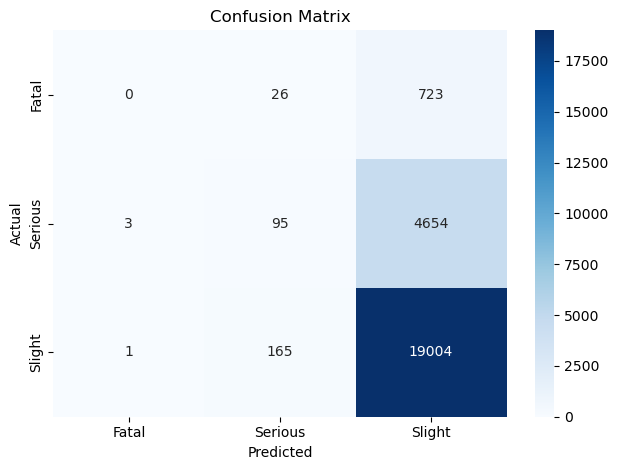

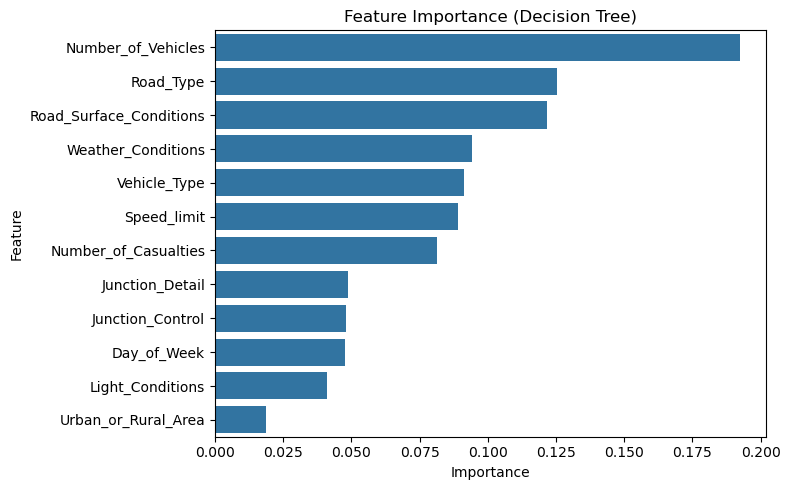


Model and encoders saved successfully!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib

df = pd.read_csv("Road Accident Data.csv")

FEATURES = [
    "Speed_limit",
    "Weather_Conditions",
    "Road_Surface_Conditions",
    "Light_Conditions",
    "Road_Type",
    "Vehicle_Type",
    "Number_of_Vehicles",
    "Number_of_Casualties",
    "Junction_Control",
    "Junction_Detail",
    "Day_of_Week",
    "Urban_or_Rural_Area",
]
TARGET = "Accident_Severity"

UNUSED_COLUMNS = [
    "Accident_Index",
    "Accident Date",
    "Month",
    "Year",
    "Latitude",
    "Local_Authority_(District)",
    "Carriageway_Hazards",
    "Longitude",
    "Police_Force",
    "Time",
]

# dropping columns
df = df.drop(columns=UNUSED_COLUMNS)
print("Missing values in remaining columns:\n", df.isnull().sum())

df = df.dropna()
df = df.drop_duplicates()
print("\nDataset shape after proper cleaning:", df.shape)

encoders = {}
# Encoding
for col in df.select_dtypes(include="object").columns:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])
    encoders[col] = encoder

X = df[FEATURES]
y = df[TARGET]

print("\nClass distribution (this is why 'accuracy' alone is misleading):")
label_map = dict(enumerate(encoders[TARGET].classes_))
print(y.map(label_map).value_counts(normalize=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\n=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=encoders[TARGET].classes_))

best_pred = y_pred

cm = confusion_matrix(y_test, best_pred)
plt.figure()
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=encoders[TARGET].classes_,
    yticklabels=encoders[TARGET].classes_,
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_,
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance, x="Importance", y="Feature")
plt.title("Feature Importance (Decision Tree)")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

joblib.dump(model, "accident_model.pkl")
joblib.dump(encoders, "encoders.pkl")
print("\nModel and encoders saved successfully!")

In [2]:
%%writefile accident_app.py
import streamlit as st
import pandas as pd
import joblib

model = joblib.load("accident_model.pkl")
encoders = joblib.load("encoders.pkl")

st.set_page_config(
    page_title="SafeRoad AI",
    page_icon="🚗",
    layout="centered"
)

# ---------------- SIDEBAR NAVIGATION ----------------
st.sidebar.title("🚗 SafeRoad AI")
st.sidebar.image(
    "https://tse2.mm.bing.net/th/id/OIP.UYUJI3uy5b_zP0Sr259e3QHaEP?r=0&rs=1&pid=ImgDetMain&o=7&rm=3",
    use_container_width=True
)
st.sidebar.write(
        "Welcome to SafeRoad AI! Use the sidebar to navigate through "
        "sections, learn why this app was built, and try out the "
        "accident severity predictor."
    )

page = st.sidebar.selectbox(
    "Select a Section",
    [ "About The App", "Prediction"]
)

st.sidebar.divider()
st.sidebar.caption("Built as a demo project for road safety awareness.")

# ----------------  ----------------
if page == "About The App":
    st.title("🚗 SafeRoad AI")
    st.subheader("Road Accident Severity Predictor")

    st.image(
        "https://tse4.mm.bing.net/th/id/OIP.-5qiUzo1xU5LFvcOsVEUgwHaEK?r=0&rs=1&pid=ImgDetMain&o=7&rm=3",
        use_container_width=True
    )
    st.write(
        "Road accidents remain one of the leading causes of death and injury worldwide, but the outcome rarely"
        "depends on speed or vehicle count alone. Weather, road surface, and lighting conditions all affect how well"
        "a driver can see and control their vehicle. Road type, vehicle type, and junction details add further risk,"
        "especially at intersections. Even the day of the week and whether the area is urban or rural can influence"
        "accident patterns. Together,these factors show that road safety is shaped by many conditions working together, not just one."
    )
    
    st.write(
        "SafeRoad AI uses a machine learning model trained on real "
        "accident records to estimate how severe an accident might be, "
        "based on the conditions you provide. The goal is to raise "
        "awareness of how these factors combine to affect outcomes — "
        "not to replace real safety assessments."
    )

# ---------------- PREDICTION PAGE ----------------
elif page == "Prediction":
    st.title("🚗 SafeRoad AI")
    st.subheader("Road Accident Severity Predictor")

    st.write(
        "Fill in the details below to see how factors like speed, "
        "weather, and road conditions can influence accident severity."
    )
    st.divider()

    FEATURES = [
        "Speed_limit",
        "Weather_Conditions",
        "Road_Surface_Conditions",
        "Light_Conditions",
        "Road_Type",
        "Vehicle_Type",
        "Number_of_Vehicles",
        "Number_of_Casualties",
        "Junction_Control",
        "Junction_Detail",
        "Day_of_Week",
        "Urban_or_Rural_Area"
    ]
    TARGET = "Accident_Severity"
    NUMERIC_FEATURES = [
        "Speed_limit",
        "Number_of_Vehicles",
        "Number_of_Casualties"
    ]

    user_input = {}

    st.markdown("## Numeric Details")
    user_input["Speed_limit"] = st.number_input(
        "Speed Limit",
        min_value=20,
        max_value=100,
        value=30
    )
    user_input["Number_of_Vehicles"] = st.number_input(
        "Number of Vehicles",
        min_value=1,
        max_value=10,
        value=2
    )
    user_input["Number_of_Casualties"] = st.number_input(
        "Number of Casualties",
        min_value=0,
        max_value=20,
        value=1
    )

    st.markdown("## Conditions")
    for col in FEATURES:
        if col in NUMERIC_FEATURES:
            continue
        options = list(encoders[col].classes_)
        user_input[col] = st.selectbox(
            col.replace("_", " "),
            options
        )

    if st.button("🚦 Predict Severity"):
        row = {}
        for col in FEATURES:
            if col in encoders:
                row[col] = encoders[col].transform(
                    [user_input[col]]
                )[0]
            else:
                row[col] = user_input[col]

        input_df = pd.DataFrame(
            [row],
            columns=FEATURES
        )

        prediction = model.predict(input_df)[0]
        prediction_label = encoders[TARGET].inverse_transform(
            [prediction]
        )[0]

        if prediction_label.lower() == "fatal":
            st.error("🚨 Predicted Severity: FATAL")
        elif prediction_label.lower() == "serious":
            st.warning("⚠️ Predicted Severity: SERIOUS")
        else:
            st.success("✅ Predicted Severity: SLIGHT")

        st.markdown("## Prediction Confidence")
        probabilities = model.predict_proba(input_df)[0]
        labels = encoders[TARGET].classes_
        colors = {
            "Fatal": "#FF2B2B",
            "Serious": "#FFA500",
            "Slight": "#00C853"
        }

        for label, prob in zip(labels, probabilities):
            percentage = prob * 100
            color = colors.get(
                label,
                "#3399FF"
            )
            html = f"""
<div style="margin-bottom:20px;">
    <div style="
        display:flex;
        justify-content:space-between;
        color:white;
        font-weight:bold;
        margin-bottom:6px;
    ">
        <span>{label}</span>
        <span>{percentage:.2f}%</span>
    </div>
    <div style="
        background:#2E2E3A;
        border-radius:10px;
        height:18px;
        width:100%;
        overflow:hidden;
    ">
        <div style="
            background:{color};
            width:{percentage:.2f}%;
            height:18px;
            border-radius:10px;
        ">
        </div>
    </div>
</div>
"""
            st.html(html)

Overwriting accident_app.py


In [ ]:
!streamlit run accident_app.py